# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | First Name | Last Name | Signature | Hours | Contribution |
| Member 2: | First Name | Last Name | Signature | Hours | Contribution |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

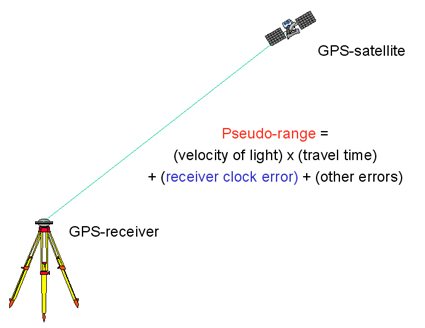

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

# Drive mount
from google.colab import drive
drive.mount('/content/drive')

df_pseudorange = pd.read_excel('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment 2 Data/part1_data/pseudoranges.xlsx')[["Satellite_ID","P"]]
df_sat_pos = pd.read_excel('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment 2 Data/part1_data/satellite_position.xlsx')[["Satellite_ID","x","y","z"]]

# Inner-join to guarantee same satellites and ordering
df = df_sat_pos.merge(df_pseudorange, on="Satellite_ID", how="inner").sort_values("Satellite_ID").reset_index(drop=True)

# Numpy arrays in the correct shapes
sat_pos     = df[["x","y","z"]].to_numpy(float)     # (N,3)
pseudorange = df["P"].to_numpy(float).reshape(-1)   # (N,)

np.random.seed(42) #for reproducible results
pseudorange = pseudorange + np.random.uniform(0.0, 0.5, size=pseudorange.shape)

#for checking if correct shapes
print('pseudorange.shape =', pseudorange.shape)  # expect (11,)
print('sat_pos.shape     =', sat_pos.shape)      # expect (11, 3) for 11 satellites

Mounted at /content/drive
pseudorange.shape = (11,)
sat_pos.shape     = (11, 3)


In [15]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]   # number of pseudorange measurements
m = 4                      # [X, Y, Z, cdT] - unknown states vector

n, m

(11, 4)

In [16]:
# GroundTruth coordinates of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [17]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)

def euclidean_norm(receiver_pos, satellite_pos):

    rec = np.asarray(receiver_pos, float).reshape(1, 3)
    sat = np.asarray(satellite_pos, float).reshape(-1, 3)
    distance = np.linalg.norm(sat - rec, axis=1)

    return distance # (N,) -> distance in meters

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [18]:
sigma2 = 1.2

P = (1 / sigma2) * np.eye(n)   # n x n diagonal weight matrix

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [19]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0], dtype=float)

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [20]:
delta = np.full(4, 10.0, dtype=float)   # initial correction value (vector)
iter_count = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []              # store weights or cost (optional use later)
arr_delta = []          # store delta values
arr_err_pos = []        # store position error per iteration
arr_i = []              # store iteration indices

# estimated state starts as the initial guess
x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [21]:
def design_matrix(x_hat, satellite_pos, distance): # (N, 4)

    # columns = [dρ/dx, dρ/dy, dρ/dz, dρ/dbias] = [(sx-rx)/ρ, (sy-ry)/ρ, (sz-rz)/ρ, -1]
    # 'distance' must be a length-N vector of ρ values (geometric ranges).

    # ensure correct shapes
    x_hat = np.asarray(x_hat, float).reshape(4,)
    satellite_pos = np.asarray(satellite_pos, float).reshape(-1, 3)
    distance = np.asarray(distance, float).reshape(-1,)

    # receiver estimated position (ignore clock term)
    xr, yr, zr, _ = x_hat

    # Line-of-sight (LOS) vectors
    diff = satellite_pos - np.array([xr, yr, zr]) # (n, 3)

    # LOS unit vectors
    u = diff / distance[:, None]                  # (n, 3)

    # construct design matrix A
    n = satellite_pos.shape[0]
    A = np.empty((n, 4))
    A[:, 0:3] = -u                             # partials wrt position
    A[:, 3] = -1.0                             # partial wrt clock bias

    return A
    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [22]:
corr_delta = 0.008
max_iterations = 10000
iter_count = 0

while iter_count < max_iterations:

  iter_count += 1  # increment at start of the iteration

  # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
  # (0.5 marks)
  distance = euclidean_norm(x_hat[:3], sat_pos)            # (N,)

  # compute the design matrix A
  # (0.5 marks)
  A        = design_matrix(x_hat, sat_pos, distance)       # (N,4)

  # compute the misclosure array w
  # (0.5 marks)
  computed = distance - x_hat[3]
  w        = pseudorange - computed                        # (N,)

  # compute the corrections delta
  # (0.5 marks)
  N = A.T @ P @ A
  u = A.T @ P @ w
  delta = np.linalg.solve(N, u)                   # corrections ΔX (4,)

  # update the states vector
  x_hat = x_hat + delta

  # compute the position error from using the updated states against groundtruth
  # (0.5 marks)
  err_pos = x_hat[:3] - GroundTruth   # 3D error vector

  # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
  # (0.5 marks)

  arr_w.append(w.copy())             # misclosure vector (shape n)
  arr_delta.append(delta.copy())     # correction vector (shape 4)
  arr_err_pos.append(err_pos.copy()) # scalar position error
  arr_i.append(iter_count)           # iteration number

  if np.linalg.norm(delta[0:3]) < corr_delta:
    print("Converged in", iter_count, "iterations.")
    break

# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
apv = (w.T @ P @ w) / (n - m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.inv(N)

print("\nx_hat [X,Y,Z,cdT] (m):", np.round(x_hat, 6))
print("Final 3D error (m):", np.round(err_pos, 6))




Converged in 5 iterations.

x_hat [X,Y,Z,cdT] (m): [-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70248000e+00]
Final 3D error (m): [-3.076349 -2.350835  3.801181]


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [23]:
# your code here

# 1. Estimated states
print("Estimated States (x_hat) [X, Y, Z, cdT] (meters):")
print(np.round(x_hat, 6), "\n")

# 2. Final corrections (last delta)
print("Final Corrections (delta) (meters):")
print(delta, "\n")

# 3. Measurement residuals (w = observed - computed)
print("Residuals (w) (meters):")
print(np.round(w, 6), "\n")
print("RMS residual (m):")
print(np.round(np.sqrt(np.mean(w ** 2)), 6), "\n")

# 4. A Posteriori Variance of Unit Weight (sigma_0^2)
print("A Posteriori Variance of Unit Weight (σ₀²):")
print(np.round(apv, 6), "\n")

# 5. Covariance matrix of estimated states
print("Covariance Matrix of Estimated States C_x_hat (m²):")
print(np.round(C_x_hat, 6), "\n")

# 6. Number of iterations
print("Number of Iterations:")
print(iter_count, "\n")

# 7. Final 3-D position error
pos_error = np.linalg.norm(x_hat[:3] - GroundTruth)
print("Final 3-D Position Error (meters):")
print(np.round(pos_error, 6))


Estimated States (x_hat) [X, Y, Z, cdT] (meters):
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70248000e+00] 

Final Corrections (delta) (meters):
[ 3.24330127e-06  6.43110010e-06 -1.77329652e-05  2.09957835e-05] 

Residuals (w) (meters):
[ 0.204832  0.342405 -0.98044   0.065998  0.047086 -1.570802 -0.309209
  1.699577  0.335242  0.74094  -0.57575 ] 

RMS residual (m):
0.829649 

A Posteriori Variance of Unit Weight (σ₀²):
0.901368 

Covariance Matrix of Estimated States C_x_hat (m²):
[[ 0.345747  0.07535  -0.091477  0.079034]
 [ 0.07535   0.460205 -0.628511  0.398324]
 [-0.091477 -0.628511  2.212607 -1.194154]
 [ 0.079034  0.398324 -1.194154  0.756346]] 

Number of Iterations:
5 

Final 3-D Position Error (meters):
5.425802


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [24]:
# your answer here

# Ans- The APV (σ₀² ≈ 0.901) is nearly equal to 1.0 and demonstrates that the assumed observation variance (1.2 m²) aligned with the
# actual measurement noise present in the pseudoranges.
# A value that is slightly lower than 1.0 indicates the measurements fit slightly better than expected, nonetheless, remains within realistic bounds.
# This is a clear and reassuring indication that the model, the linearization, and the weighting were each reasonable for the data.

# The covariance matrix contains the estimated uncertainties of the four unknowns X, Y, Z, and cdT.
# The smallness of the diagonal elements indicates that the receiver's position and the bias in the clock were determined reasonably well.
# The off-diagonal terms indicate the correlation among parameters:
# X, Y, and Z are moderately correlated, since the satellite geometry couples the three components of position.
# cdT is also correlated with position, which is what one would expect as clock bias shifts all ranges the same distance.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

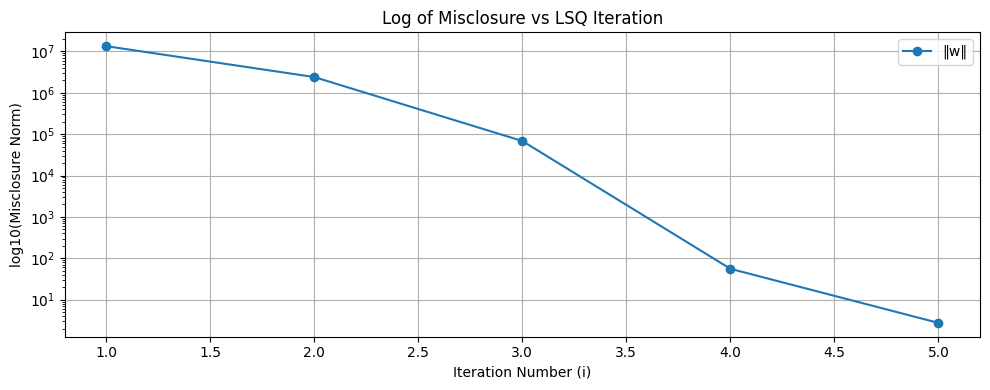

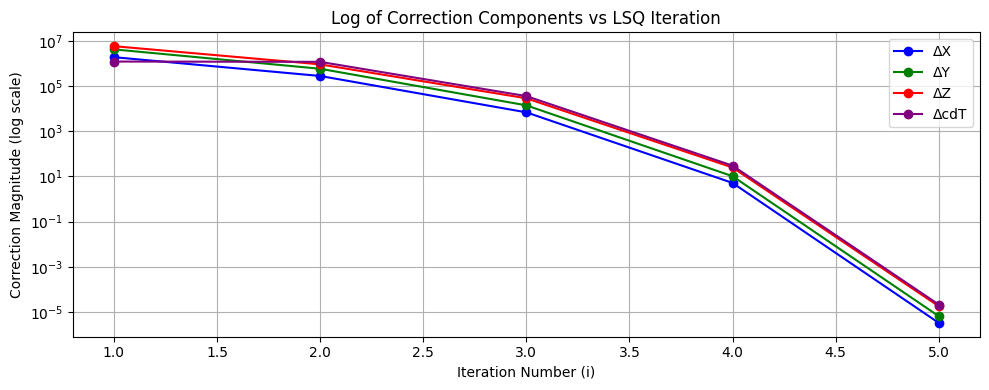

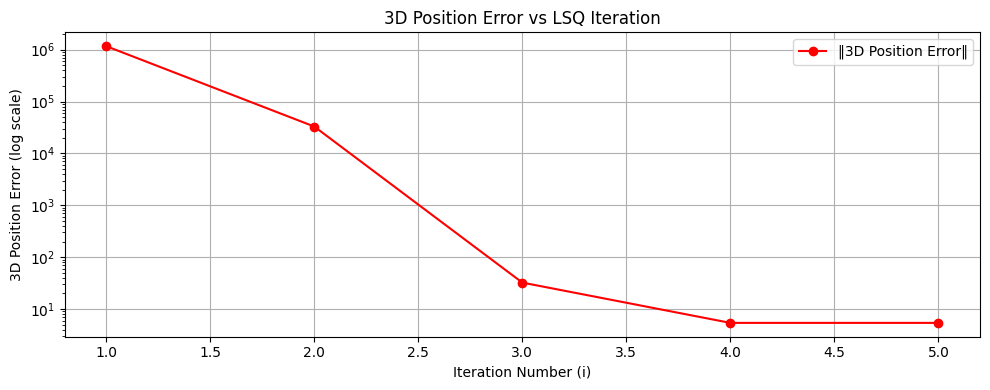

Comment:
Overall, the three plots exhibit rapidly diminishing values that asymptotically stabilize, demonstrating the progressive reduction of modeling errors and parameter updates as the least squares estimation (LSE) algorithm converges to a consistent and reliable receiver position estimate.


In [25]:
# Ensure arrays are numpy arrays
arr_w = np.array(arr_w)
arr_delta = np.array(arr_delta)
arr_err_pos = np.array(arr_err_pos)
arr_i = np.array(arr_i)


# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)

# Compute misclosure norms
w_norm = np.linalg.norm(arr_w, axis=1)

plt.figure(figsize=(10, 4))
plt.semilogy(arr_i, w_norm, marker='o', linestyle='-', label='‖w‖')

plt.xlabel("Iteration Number (i)")
plt.ylabel("log10(Misclosure Norm)")
plt.title("Log of Misclosure vs LSQ Iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)

plt.figure(figsize=(10, 4))

labels = ["ΔX", "ΔY", "ΔZ", "ΔcdT"]
colors = ["blue", "green", "red", "purple"]

for k in range(4):
    plt.semilogy( arr_i,
                  np.abs(arr_delta[:, k]) + 1e-12,    # avoid log(0)
                  marker='o',
                  linestyle='-',
                  color=colors[k],
                  label=labels[k] )

plt.xlabel("Iteration Number (i)")
plt.ylabel("Correction Magnitude (log scale)")
plt.title("Log of Correction Components vs LSQ Iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)

pos_err_norm = np.linalg.norm(arr_err_pos, axis=1)

plt.figure(figsize=(10, 4))

plt.semilogy(arr_i,
             pos_err_norm + 1e-12,
             marker='o',
             linestyle='-',
             color='red',
             label='‖3D Position Error‖')

plt.xlabel("Iteration Number (i)")
plt.ylabel("3D Position Error (log scale)")
plt.title("3D Position Error vs LSQ Iteration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Comment:")
print("Overall, the three plots exhibit rapidly diminishing values that asymptotically stabilize, demonstrating the progressive reduction of modeling errors and parameter updates as the least squares estimation (LSE) algorithm converges to a consistent and reliable receiver position estimate.")

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [26]:
# Ans - In conclusion, the three plots show exhibit values that quickly decay and eventually stabilize asymptotically, reflecting the gradual decline of modeling
# error and updates to the parameters as the least squares estimation (LSE) algorithm estimates a consistent and reliable receiver position.


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [27]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [28]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges


def cost_function(rec_pos, cdT, sat_pos, pseudorange):

    distance  = euclidean_norm(rec_pos, sat_pos)   # (N,)
    predicted = distance - cdT                     # (N,)
    residuals = pseudorange - predicted            # (N,)
    L = (1/n) * np.sum(residuals ** 2)
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [36]:
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    # Ensure correct shapes for input
    rec_pos_array = np.asarray(rec_pos, float).reshape(3,)
    cdT_scalar = np.asarray(cdT, float).item()
    satellite_pos_array = np.asarray(sat_pos, float).reshape(-1, 3)
    pseudorange_array = np.asarray(pseudorange, float).reshape(-1,)

    # Calculate geometric distances (rho)
    distance = euclidean_norm(rec_pos_array, satellite_pos_array) # (N,)

    # Predicted pseudoranges
    predicted_pseudorange = distance - cdT_scalar # (N,)

    # Residuals: observed - predicted
    residuals = pseudorange_array - predicted_pseudorange # (N,)

    # Design matrix A, where A_ij = d(predicted_pseudorange_i) / dX_j
    # The previous `design_matrix` function calculates A such that:
    # A[:, 0:3] = - (sx-rx)/rho, -(sy-ry)/rho, -(sz-rz)/rho
    # A[:, 3] = -1
    # So, d(predicted_pseudorange_i)/dX_j corresponds to the negative of A as defined in `design_matrix`

    # However, the gradient of L = (1/N) * sum(residuals^2) with respect to X
    # is (2/N) * sum(residuals * d(residuals)/dX)
    # And d(residuals)/dX = d(pseudorange - (rho - cdT))/dX = -d(rho - cdT)/dX
    # The design matrix A was set up such that A_ij = d(rho_i - cdT_i)/dX_j
    # So, d(residuals)/dX = -A
    # Therefore, gradient = (2/N) * sum(residuals * (-A)) = -(2/N) * A.T @ residuals

    # For this implementation, let's use the definition of A that's consistent with the derivation of the gradient.
    # The `design_matrix` function computes A = [ (sx-rx)/rho, (sy-ry)/rho, (sz-rz)/rho, -1 ]
    # We need the partial derivatives of the predicted pseudorange (rho - cdT) w.r.t [xr, yr, zr, cdT]
    # d(rho - cdT)/dxr = (xr - sx)/rho = - (sx - xr)/rho
    # d(rho - cdT)/dyr = (yr - sy)/rho = - (sy - yr)/rho
    # d(rho - cdT)/dzr = (zr - sz)/rho = - (sz - zr)/rho
    # d(rho - cdT)/dcdT = -1
    # This is exactly what the `design_matrix` function returns, so we can use it directly.

    # Get the design matrix A which holds the partial derivatives of (rho - cdT)
    # (x_hat for design matrix is [rec_pos, cdT])
    x_hat_for_A = np.append(rec_pos_array, cdT_scalar) # (4,)
    A = design_matrix(x_hat_for_A, satellite_pos_array, distance) # (N,4)

    # The gradient of the cost function (sum of squared residuals) is given by:
    # grad_L = (2/n) * A_prime.T @ residuals
    # where A_prime are the partial derivatives of the predicted measurement (rho - cdT) w.r.t the states.
    # As currently implemented, `design_matrix` returns the partials of `rho - cdT` w.r.t `xr, yr, zr, cdT`.
    # Let f_i(X) = rho_i(X) - cdT.
    # The cost is L = (1/n) * sum( (pseudorange_i - f_i(X))^2 )
    # dL/dX = (1/n) * sum( 2 * (pseudorange_i - f_i(X)) * (-d(f_i(X))/dX) )
    #       = -(2/n) * sum( residuals_i * (d(f_i(X))/dX) )
    #       = -(2/n) * A.T @ residuals

    # Correcting A for the gradient calculation: `design_matrix` computes partials of `rho` w.r.t. `rx, ry, rz` and `-1` for `cdT`.
    # The partials of `(rho - cdT)` w.r.t. `rx, ry, rz` are `(rx - sx)/rho`, `(ry - sy)/rho`, `(rz - sz)/rho`.
    # The partial of `(rho - cdT)` w.r.t. `cdT` is `-1`.
    # The `design_matrix` function currently calculates A[:,0:3] = -u = -[(sx-rx)/rho, (sy-ry)/rho, (sz-rz)/rho]
    # which is `[(rx-sx)/rho, (ry-sy)/rho, (rz-sz)/rho]` for the first three columns.
    # And A[:,3] = -1.
    # So, the A from `design_matrix` is correct for `d(rho-cdT)/dX`.

    gradient_vector = -(2/n) * A.T @ residuals

    return gradient_vector

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [37]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count
    print("Learning Rate:")
    print(learning_rate)

    #initalize the estimates as zeros
    X = np.array([0,0,0,0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)


        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print(f"Converged after {iteration} iterations.")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X, arr_cost, arr_grad, arr_err

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [38]:
optimized_params, arr_cost, arr_grad, arr_err = gradient_descent(pseudorange, sat_pos)
final_position_errors = arr_err[-1]
final_cost = arr_cost[-1]
final_gradient = arr_grad[-1]

# print the mentioned metrics
print("Optimized Parameters:", optimized_params)
print("Final Position Errors (Vector):", final_position_errors)
print("Final Position Errors (Norm):", np.round(np.linalg.norm(np.array(final_position_errors)),6))
print("Steps Taken:", steps_count)
print("Final Cost:", arr_cost[-1])
print("Final Gradient:", arr_grad[-1])

Learning Rate:
0.08
Converged after 3707 iterations.
Optimized Parameters: [-1.63349245e+06 -3.65162952e+06  4.95248538e+06 -6.67895963e+00]
Final Position Errors (Vector): [-3.07392655 -2.33733685  3.75969368]
Final Position Errors (Norm): 5.38957
Steps Taken: 3707
Final Cost: 0.6883960844682057
Final Gradient: [ 0.0001545   0.00086087 -0.00264581  0.00149998]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

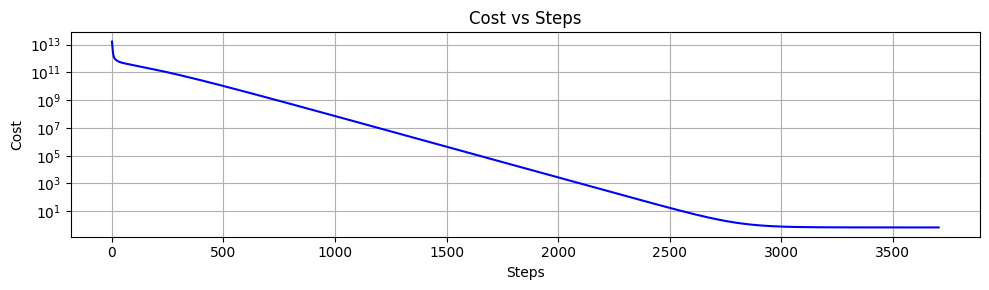

Comment:
The cost decreases rapidly at first and then gradually levels off, indicating that gradient descent quickly reduces large initial residuals and then converges steadily as the solution approaches the optimal receiver position.


In [39]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
ax.semilogy(arr_cost, linestyle= '-', color='b')
ax.set_xlabel("Steps")
ax.set_ylabel("Cost")
ax.set_title("Cost vs Steps")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The cost decreases rapidly at first and then gradually levels off, indicating that gradient descent quickly reduces large initial residuals and then converges steadily as the solution approaches the optimal receiver position.

print("Comment:")
print("The cost decreases rapidly at first and then gradually levels off, indicating that gradient descent quickly reduces large initial residuals and then converges steadily as the solution approaches the optimal receiver position.")

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

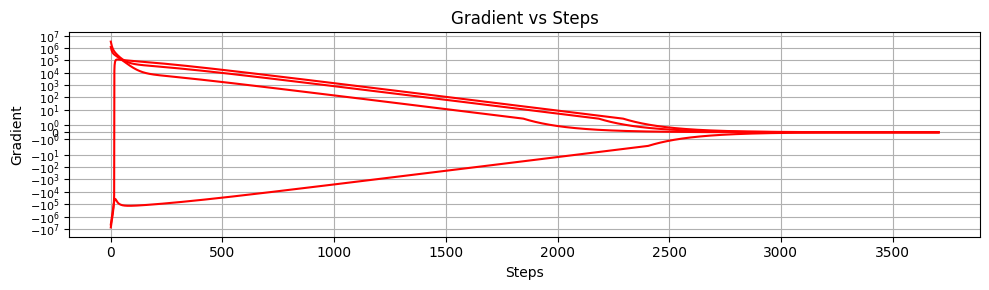

Comment:
The gradients decrease toward zero over the iterations, indicating that the updates diminish as the algorithm converges to the optimal solution.


In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
ax.plot(arr_grad, linestyle= '-', color='red')
ax.set_yscale('symlog')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel("Steps")
ax.set_ylabel("Gradient")
ax.set_title("Gradient vs Steps")
ax.grid(True)
fig.tight_layout()
plt.show()


# Comment on the pattern
# The gradients decrease toward zero over the iterations, indicating that the updates diminish as the algorithm converges to the optimal solution.

print("Comment:")
print("The gradients decrease toward zero over the iterations, indicating that the updates diminish as the algorithm converges to the optimal solution.")

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

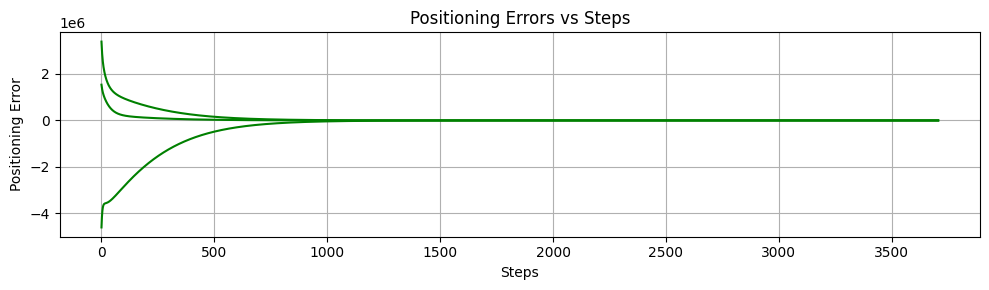

Comment:
The positioning errors decrease steadily with each iteration, demonstrating that the estimated receiver coordinates progressively approach the true position as the optimization converges.


In [42]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
ax.plot(arr_err, linestyle='-', color='green')
ax.set_xlabel("Steps")
ax.set_ylabel("Positioning Error")
ax.set_title("Positioning Errors vs Steps")
ax.grid(True)
fig.tight_layout()
plt.show()


# Comment on the pattern
# The positioning errors decrease steadily with each iteration, demonstrating that the estimated receiver coordinates progressively approach the true position as the optimization converges.

print("Comment:")
print("The positioning errors decrease steadily with each iteration, demonstrating that the estimated receiver coordinates progressively approach the true position as the optimization converges.")

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [43]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost = []
arr_grad = []
arr_err = []
steps_count = 0

optimized_params_2, arr_cost, arr_grad, arr_err = gradient_descent(pseudorange, sat_pos,0.008)

# print the metrics
print("Optimized Parameters:", optimized_params_2)

Learning Rate:
0.008
Optimized Parameters: [-1631144.48068779 -3638563.47142052  4912335.29174992    22781.54596278]


In [44]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost = []
arr_grad = []
arr_err = []
steps_count = 0

optimized_params_2, arr_cost, arr_grad, arr_err = gradient_descent(pseudorange, sat_pos,0.0008)

# print the metrics
print("Optimized Parameters:", optimized_params_2)

Learning Rate:
0.0008
Optimized Parameters: [-1415988.07192269 -2697204.26743853  2102928.07089903  1743644.6535703 ]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Ans 1- A higher learning rate (0.008) converges faster, but it may also lead to instability or a poor estimate. A lower learning rate (0.0008) is slower to converge,
# but it is more stable; therefore, it may not find the correct solution in the iteration limit.

# Ans 2 - The LSE converges quickly, and it provides a relatively direct and robust statistical solution. Because gradient descent only converges to the overall
# objective of iterative improvement, it typically requires many iterations with precise tuning to reach similar conditions as a LSE calculus.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [48]:
# Load the Student Depression Dataset
from google.colab import drive
drive.mount ('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment 2 Data/part2_data/Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop(columns=['id'])  # Remove irrelevant ID column
data = data.dropna()  # Remove rows with missing values
data = data.drop_duplicates()  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# your code here
data = data[~(data == 'Other').any(axis=1)]

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
# your code here
print("Shape after preprocessing:", data.shape)
print(data.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape after preprocessing: (27898, 17)
   Gender   Age           City Profession  Academic Pressure  Work Pressure  \
0    Male  33.0  Visakhapatnam    Student                5.0            0.0   
1  Female  24.0      Bangalore    Student                2.0            0.0   
2    Male  31.0       Srinagar    Student                3.0            0.0   
3  Female  28.0       Varanasi    Student                3.0            0.0   
4  Female  25.0         Jaipur    Student                4.0            0.0   

   CGPA  Study Satisfaction  Job Satisfaction     Sleep Duration  \
0  8.97                 2.0               0.0          5-6 hours   
1  5.90                 5.0               0.0          5-6 hours   
2  7.03                 5.0               0.0  Less than 5 hours   
3  5.59                 2.0               0.0          7-8 hours   
4  8.13          

In [49]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression'] # Target vector
X = data.drop('Depression', axis=1) # Feature matrix

# Display sizes of X and y
# your code here
print("Size of X:",X.shape)
print("Size of y:",y.shape)

Size of X: (27898, 16)
Size of y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

Class 1 (Depression): 16335
Class 0 (No Depression): 11563


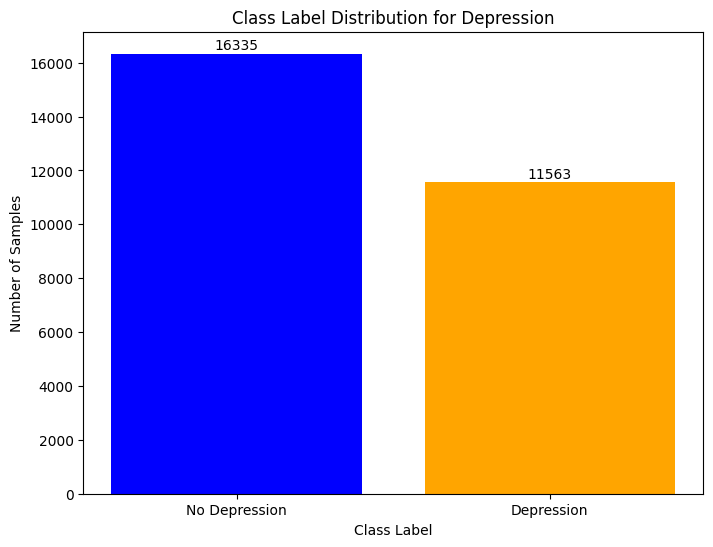

In [50]:
# Check the class distribution of y
class_counts = y.value_counts()

# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here
for label, count in class_counts.items():
    if label == 0:
        label_name = "No Depression"
    else:
        label_name = "Depression"
    print(f"Class {label} ({label_name}): {count}")

plt.figure(figsize=(8, 6))
bars = plt.bar(class_counts.index.map(str), class_counts.values, color=['blue', 'orange'])
for bar, class_idx in zip(bars, class_counts.index):
    yval = bar.get_height()
    label_name = "No Depression" if class_idx == 0 else "Depression"
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Label Distribution for Depression')
plt.xticks(class_counts.index.map(str), ["No Depression", "Depression"])
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [51]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(X, y, test_size=0.97, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
print("Size of X_small:",X_small.shape)
print("Size of y_small:",y_small.shape)

Size of X_small: (836, 16)
Size of y_small: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate the model
model = LogisticRegression(max_iter=2000)

# 1. Train and evaluate on full X and y
model.fit(X, y)
y_pred = model.predict(X)
print("Accuracy with X and y:", accuracy_score(y, y_pred))
print("Classification Report with X and y:\n", classification_report(y, y_pred))

# 2. Train and evaluate using only the first two columns of X
X_first_two_columns = X.iloc[:, :2]
model.fit(X_first_two_columns, y)
y_pred_first_two = model.predict(X_first_two_columns)
print("Accuracy with first two columns of X and y:", accuracy_score(y, y_pred_first_two))
print("Classification Report with first two columns of X and y:\n", classification_report(y, y_pred_first_two))

# 3. Train and evaluate on small subset (X_small, y_small)
model.fit(X_small, y_small)
y_pred_small = model.predict(X_small)
print("Accuracy with X_small and y_small:", accuracy_score(y_small, y_pred_small))
print("Classification Report with X_small and y_small:\n", classification_report(y_small, y_pred_small))

Accuracy with X and y: 0.846118001290415
Classification Report with X and y:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81     11563
           1       0.86      0.89      0.87     16335

    accuracy                           0.85     27898
   macro avg       0.84      0.84      0.84     27898
weighted avg       0.85      0.85      0.85     27898

Accuracy with first two columns of X and y: 0.6324467703778048
Classification Report with first two columns of X and y:
               precision    recall  f1-score   support

           0       0.59      0.37      0.45     11563
           1       0.65      0.82      0.72     16335

    accuracy                           0.63     27898
   macro avg       0.62      0.59      0.59     27898
weighted avg       0.62      0.63      0.61     27898

Accuracy with X_small and y_small: 0.8564593301435407
Classification Report with X_small and y_small:
               precision    recall  f1-score 

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

# Function to calculate and print the required metric
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Testing accuracy
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Log loss (on test)
    y_test_prob = model.predict_proba(X_test)
    test_log_loss = log_loss(y_test, y_test_prob)

    # Print results
    print("Data size:", X_train.shape[0] + X_test.shape[0])
    print("Number of training samples:", X_train.shape[0])
    print("Number of testing samples:", X_test.shape[0])
    print("Training accuracy:", train_accuracy)
    print("Testing accuracy:", test_accuracy)
    print("Log loss:", test_log_loss)

# Create a smaller dataset with 3% of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instantiate the model
model = LogisticRegression(max_iter=2000)

# Evaluate the model with the full dataset (X and y)
model.fit(X_train, y_train)
print("Evaluation with X and y:")
evaluate_model(model, X_train, y_train, X_test, y_test)

# Evaluate the model with only the first two columns of X and y
X_first_two = X.iloc[:, :2]
X_first_two_train, X_first_two_test, y_first_two_train, y_first_two_test = train_test_split(X_first_two, y, test_size=0.3, random_state=42)
model.fit(X_first_two_train, y_first_two_train)
print("\nEvaluation with first two columns of X and y:")
evaluate_model(model, X_first_two_train, y_first_two_train, X_first_two_test, y_first_two_test)

# Evaluate the model with the smaller dataset (X_small and y_small)
X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small, y_small, test_size=0.3, random_state=42)
model.fit(X_small_train, y_small_train)
print("\nEvaluation with X_small and y_small:")
evaluate_model(model, X_small_train, y_small_train, X_small_test, y_small_test)

Evaluation with X and y:
Data size: 27898
Number of training samples: 19528
Number of testing samples: 8370
Training accuracy: 0.846937730438345
Testing accuracy: 0.8462365591397849
Log loss: 0.3498343886395724

Evaluation with first two columns of X and y:
Data size: 27898
Number of training samples: 19528
Number of testing samples: 8370
Training accuracy: 0.6341151167554281
Testing accuracy: 0.6285543608124253
Log loss: 0.6531680189656458

Evaluation with X_small and y_small:
Data size: 836
Number of training samples: 585
Number of testing samples: 251
Training accuracy: 0.8666666666666667
Testing accuracy: 0.8207171314741036
Log loss: 0.37457076234736403


### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [54]:
# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import pandas as pd

# Assume X, y, X_small, y_small are already available from previous steps

# Function to calculate and return the required metrics
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Calculate training accuracy
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    # Calculate testing accuracy
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    # Calculate log loss
    y_test_prob = model.predict_proba(X_test)
    test_log_loss = log_loss(y_test, y_test_prob)

    # Return the results as a dictionary
    return {
        "Data size": X_train.shape[0] + X_test.shape[0],
        "Training samples": X_train.shape[0],
        "Testing samples": X_test.shape[0],
        "Training accuracy": train_accuracy,
        "Testing accuracy": test_accuracy,
        "Log loss": test_log_loss
    }

# Split the data into training and testing sets for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_first_two = X.iloc[:, :2]
X_first_two_train, X_first_two_test, y_first_two_train, y_first_two_test = train_test_split(
    X_first_two, y, test_size=0.3, random_state=0)
X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(
    X_small, y_small, test_size=0.3, random_state=0)

# Instantiate the model
model = LogisticRegression(max_iter=2000)

# Evaluate the model with the full dataset (X and y)
model.fit(X_train, y_train)
results_full = evaluate_model(model, X_train, y_train, X_test, y_test)

# Evaluate the model with only the first two columns of X and y
model.fit(X_first_two_train, y_first_two_train)
results_first_two = evaluate_model(model, X_first_two_train, y_first_two_train, X_first_two_test, y_first_two_test)

# Evaluate the model with the smaller dataset (X_small and y_small)
model.fit(X_small_train, y_small_train)
results_small = evaluate_model(model, X_small_train, y_small_train, X_small_test, y_small_test)

# Create a pandas DataFrame to store the results
results_df = pd.DataFrame([results_full,results_first_two, results_small],
                          index=['Full Dataset', 'First Two Columns', 'Smaller Dataset'])

# Print the results DataFrame
print(results_df)

                   Data size  Training samples  Testing samples  \
Full Dataset           27898             19528             8370   
First Two Columns      27898             19528             8370   
Smaller Dataset          836               585              251   

                   Training accuracy  Testing accuracy  Log loss  
Full Dataset                0.846887          0.846117  0.348357  
First Two Columns           0.631708          0.634170  0.652715  
Smaller Dataset             0.854701          0.852590  0.339818  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Assuming X and y are already defined and prepared

# Split the data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Instantiate model
model = LogisticRegression(max_iter=2000)

# Train model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print dimension of predicted output
print("Dimension of the predicted output:", y_pred.shape)

# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Print classification report
class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)


Dimension of the predicted output: (8370,)
Confusion Matrix:
 [[2698  738]
 [ 550 4384]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      3436
           1       0.86      0.89      0.87      4934

    accuracy                           0.85      8370
   macro avg       0.84      0.84      0.84      8370
weighted avg       0.85      0.85      0.85      8370



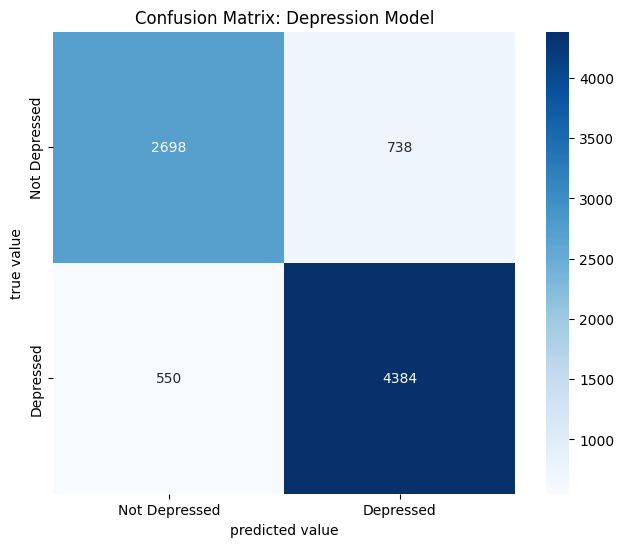

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test, y_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('predicted value')
plt.ylabel('true value')
plt.title('Confusion Matrix: Depression Model')
plt.show()

In [57]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
class_report = classification_report(y_test, y_pred, target_names=['Not Depressed', 'Depressed'])
print("Classification Report:")
print(class_report)

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.83      0.79      0.81      3436
    Depressed       0.86      0.89      0.87      4934

     accuracy                           0.85      8370
    macro avg       0.84      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split the data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Print results
    print(f"{name} accuracy: {accuracy:.4f}")



Logistic Regression accuracy: 0.8461
Naive Bayes accuracy: 0.8364
K-Nearest Neighbors accuracy: 0.7462


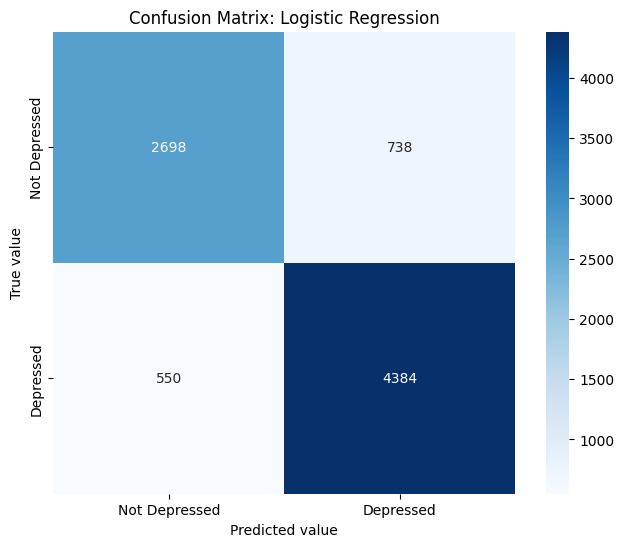

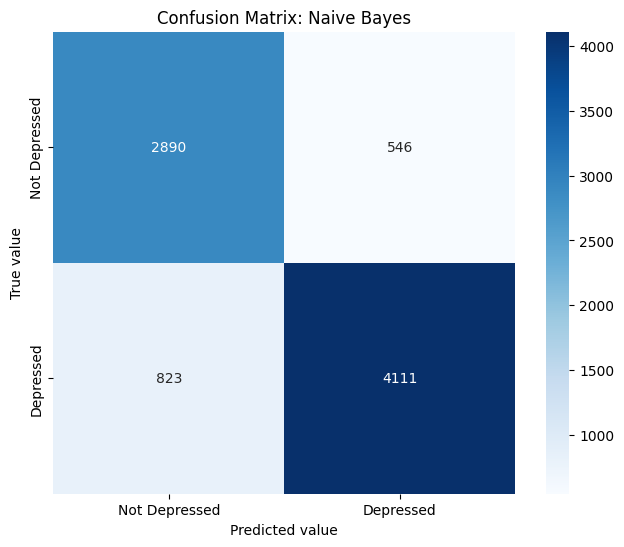

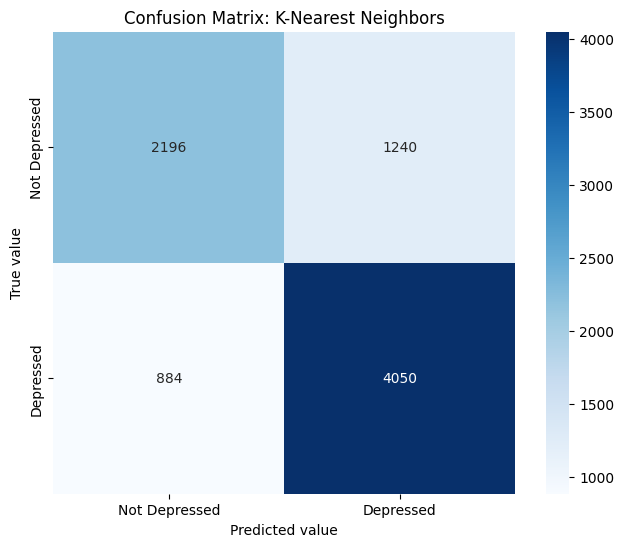

In [59]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_predictions = {}
confusion_matrices = {}

# Assuming models is your dictionary and X_test, y_test are defined
for name, model_instance in models.items():
    # Predict with the fitted model
    y_pred = model_instance.predict(X_test)
    model_predictions[name] = y_pred
    # Calculate confusion matrix
    conf_mat = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = conf_mat

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_mat,
        xticklabels=['Not Depressed', 'Depressed'],
        yticklabels=['Not Depressed', 'Depressed'],
        square=True,
        annot=True,
        cbar=True,
        fmt='d',
        cmap='Blues'
    )
    plt.xlabel('Predicted value')
    plt.ylabel('True value')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)


---
1. Yes, there is an imbalance in our dataset. It has: Class 1 (Depressed): 16,335 samples Class 0 (Not Depressed): 11,563 samples The class distributions are approximately 59% to 41%, so there is a moderate imbalance. Yes, this class imbalance will affect model performance, as in our case, the model is slightly biased for the majority class (Depressed). We see that in our classification report: ClassPrecision, Recall, F1-Score Not Depressed 0.83 0.79 0.81 Depressed 0.86 0.89 0.87 Recall is higher for the "Depressed" class (0.89 vs. 0.79), meaning the model does a better job of correctly identifying actual depressed cases than it does non-depressed cases. The model will also produce more false positives in the "Not Depressed" class, which aligns with its bias toward predicting the majority class. While the overall accuracy is still high, performance on the minority class "Not Depressed" is lower due to this imbalance, as seen in the confusion matrix and the recall scores.

---
2. Overfitting refers to a situation in which a model's performance on the training data is much better than that on the testing data, which reflects that it a) has learned specific details in the noise that are not widely applicable, instead of general regularities. Underfitting is reflected when a model's performance is significantly poor on either the training or testing data to the extent that it does not detect important relationships in the dataset. The primary way to ask to tell about overfitting and underfitting is to compare the performance metrics (cores) between the training and testing data. A substantial gap implies overfitting, poor scores on both imply underfitting, and high, similar scores imply the model is well-fitted.

**Scenario 1**: Complete Dataset (Every characteristic; X and y, divided into train and test)
Training accuracy: 0.8469
Testing accuracy: 0.8461
Observation:
Both accuracies from training and testing large and very similar.
Conclusion: The model is well-fitted. It is neither overfitting the data nor underfitting the data for the complete dataset.

**Scenario 2**: First Two Columns of X (Only two features, divided into train and test)
Training accuracy: 0.6317
Testing accuracy: 0.6342
Observation:
Both accuracies from training and testing are fairly low, indicating that the model isn't capturing the underlying patterns within the data because of very limited feature information.
Conclusion: The model is underfitting in this scenario.

**Scenario 3**: Smaller Dataset (X_small and y_small, just 3% of data)
Training accuracy: 0.8547
Testing accuracy: 0.8526
Observation:
Both training and testing accuracies are good and very close to one another, suggesting the model generalizes well (at least a small dataset) yet it performed moderately well.
Conclusion: The model is well-fitted during training and generalizing reasonably well for the small, random sample, and is not overfitting or underfitting.

---

3. According to the findings, training and testing precision do not change a great deal even when the amount of training data is greatly reduced from the complete data set (27,898 samples) to only 3% of the data (836 samples). Training precision is very small decreased from about 84.7% to about 85.5% and there is a small change in testing precision, changing from about 84.6% to about 85.3%. This minor change in precision indicates that the logistic regression model is able to generalize and identify significant patterns regardless of the amount of data it receives. It suggests that a smaller, well representative portion of the data is enough for the model to respectively reach its ceiling and increasing the total amount of data would lead to an insignificant change in accuracy.
Note:
This conclusion is not unreasonable because the smaller sample of 836 from all of the 27,898 still represents a large number of samples for logistic regression learning significant data patterns. The sample that was drawn probably represented the overall data well enough to allow the overall data to generalize well. Logistic regression is also a relatively simple model that can reach its performance limit with a smaller size representative portion of the data, even in cases where the data is not extremely complex and noisy.

This situation, however, is related to this dataset/model as reducing the size of sample tended to compromise accuracy obviously with larger representations of data and model complexity. So while the previous statement could be reasonably concluded for our purposes in this experiment, it may not hold across other datasets or machine learning models.

---

4.A false-positive result occurs when the model predicts that a student is depressed, when, in fact, they are not. Conversely, a false-negative result takes place when the model predicts that a student is not depressed, when, in fact, they are. In this regard, false negatives are more serious than false positives because false negatives imply that we have failed to identify and address students who truly need support and an intervention, which could have grave consequences for them. False positives could cause unwarranted evaluation or concern, but it is generally not as serious as a false negative. This means that it is necessary for us to improve our recall and validate most cases of depression in order to identify them and intervene, even if it increases our false positive rate.

---

5. In terms of predicting depression using the Kaggle dataset, we aim to maximize recall because the most important classification error is a false negative (model fails to identify that a student is depressed). This is dangerous for a student in need of help. Recall indicates the amount of depressed students identified. Presently, this model has a recall of .89 or 89%, indicating that 89% of actual students identified as depressed, and 11% were unreported. To improve recall (which will account for more false negatives), we want to lower the decision threshold below the standard .5 (i.e. we can lower the threshold to be more sensitive to cases of depression). After lowering the decision threshold below .5, we would increase our true positives (actual cases of depression identified by the model), however we would also increase the instances of false positives (non-depressed students flagged as depressed). Some of the tagged students may be misidentified students, which is an acceptable trade off because the impact of missing a depressed student is more serious. Other techniques to improve recall could involve oversampling the minority class or using class weights to penalize misclassification for depressed students in particular. In summary, prioritizing recall in mental health settings is particularly useful as it provides information on more campus cases of depression and thus more opportunities for help.

---

6. Based on results for the Student Depression dataset:

Full Dataset (All Features): Log Loss is 0.3484, the lowest of the three cases, indicating the model is confident and accurate in the probability predictions using all 16 different features available for all 27,898 samples.

First Two Columns Only: Log Loss rises to 0.6527, which is nearly double the Log Loss for the full dataset case. This suggests that limiting features to only two features, likely gender and age, reduces the model's information and ability to reliably identify the level of depression.

Smaller Dataset (3% of Data - 836 samples): Log Loss is 0.3398, which is better than the full dataset Log Loss due to a well-representative smaller sample that allows the model to learn reasonable patterns as it has a fair, albeit smaller, number of samples to work with.

Reason for Differences: Limitations of features constraining the model to only two attributes constrain the model's ability to account for complex factors that may contribute to depression. The smaller number of samples still yielded decent performance since the sample was representative of the student population, and 836 was enough samples, or the adequate number of samples, to develop a reasonable model using the information provided. This explains the big changes in Log Loss value for each of the cases.

---

7. Model Testing Accuracy
Logistic Regression 0.8461
Naive Bayes 0.8364
K-Nearest Neighbors 0.7462

Rationale and Assumptions:
1. Logistic Regression (Best Accuracy 0.8461): Assumes a linear relationship from the feature(s) to the log-odds of depression. Handles combination of features types. The method identifies which combinations of features are weighted more and separate well between classes. Linear relationship is apt for this dataset with both psychological and demographic features allowing for accurate calibrated (validated) predictions.

2. Naive Bayes (Accuracy 0.8364): Assumes that all features are conditionally independent given the label - not often the case in real data but certainly a simplification for learning. Although there may be a general correlation in features (e.g., academic pressure and hours study), the method is designed to capture the strongest signals, thus doing also quite well, although with just slightly less accuracy.

3. K-Nearest Neighbors (Accuracy 0.7462): Classifies based on a majority of the nearest neighbors, but higher dimension, noisy form variables do not yield the results in the way one would hope. With distance losing its meaning at high dimension it becomes difficult to classify. There is a scaling issue which can also cause it to overload or under-load features. Nonetheless, attributes in the present dataset ultimately reduce the models' accuracy as compared to either Logistic Regression or Naive Bayes.

To summarize, Logistic Regression does perform the best considering its flexibility, yet realistic assumptions of the linearity answering the questions the data attempt to model; while Naive Bayes is a best second using simplicity yet retaining a reasonable signal to noise ratio; and KNN is a challenge in the present dataset because of the high dimensionality and complexity in defining distance.

---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path =
test_csv_path =

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data =
y_train =
X_train =

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train =

# Load test data (0.5 marks)
test_data =
y_test =
X_test =

# Reshape test data to match training data format (0.5 marks)
X_test =

# Display the shapes of training and test sets


Let's visualize some sample images to understand what our models will be learning from.

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized =
X_test_normalized =

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical =
y_test_categorical =


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)


        # Another dropout layer for regularization, same with above
        # (1 marks)


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS =

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE =

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)

    ])

    # Same compile step with MLP (1 marks)
    model.compile(    )
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history =

print("CNN training completed")

### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results




Performance comparison visualization

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)




# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)









plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
